In [3]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_groq import ChatGroq
from langgraph.graph.message import add_messages

In [6]:
import os
from dotenv import load_dotenv

load_dotenv()

model = ChatGroq(
    model="openai/gpt-oss-120b",
    api_key= os.getenv("GROQ_API_KEY"),
    temperature=0,
)

In [4]:
class ChatState(TypedDict):
    
    messages: Annotated[list[BaseMessage], add_messages]

In [7]:
def chat_node(state: ChatState):

    # take user query from state
    messages = state['messages']

    # send to llm
    response = model.invoke(messages).content

    # response store state
    return {"messages": response}

In [9]:
graph = StateGraph(ChatState)

# add nodes
graph.add_node("Chat_node", chat_node)

# add edge
graph.add_edge(START, "Chat_node")
graph.add_edge("Chat_node", END)

chatbot = graph.compile()

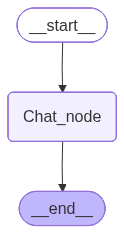

In [10]:
chatbot

In [12]:
initial_state = {
    'messages' : [HumanMessage(content="What is the capital of Bangladesh?")]
}

chatbot.invoke(initial_state)

{'messages': [HumanMessage(content='What is the capital of Bangladesh?', additional_kwargs={}, response_metadata={}, id='2e4f9d8f-49b1-47f1-8d3b-066fe819f608'),
  HumanMessage(content='The capital of Bangladesh is **Dhaka**.', additional_kwargs={}, response_metadata={}, id='122867a0-f1eb-46cd-9fad-3a4f8566636e')]}